# Introduction to Computational Physics: Problem Set 1
Tutorial: Chun Ming Yip (Group 3)

<hr>

# 0. Libaries

In [210]:
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import Papulator as pap # Custom Libary from other project
from Papulator import Sympy_Symbols as sym
from Papulator import const
import sympy as sp
import time

## 1. Introduction
In this exercise we study a quantum particle of mass $m$ in the one-dimensional finite
square well potential
$$V(x) = \begin{cases}-V_0, & |x| < a, \\ 0, & |x| \ge a, \end{cases} \quad V_0 > 0.$$

The well has depth $V_0$ and width $2a$. We seek bound states with energy
$$-V_0 < E < 0$$

This problem is fundamental in quantum mechanics and leads to transcendental
equations that cannot be solved analytically. Therefore it is an excellent application
of numerical root finding.

## 2. Schrödinger Equation
The stationary Schrödinger equation is
$$-\frac{\hbar^2}{2m}\,\frac{d^2\psi}{dx^2}+V(x)\psi=E\psi.$$
Inside the well $(|x| < a)$, the solution is oscillatory,
$$\psi(x) = A\cos(kx) + B\sin(kx),\quad k = \sqrt{\frac{2m(E+V_0)}{\hbar^2}}.$$
Outside the well $(|x| ≥ a)$, bound states decay exponentially,
$$\psi(x) \propto e^{-\kappa |x|} , \quad \kappa = \sqrt{\frac{-2 m E}{\hbar^{2}}}.$$
Because the potential is symmetric, solutions have definite parity,
+ even states: $\psi(−x) = \psi(x)$
+ odd states: $\psi(−x) = -\psi(x)$

Matching $\psi$ and $\psi'$ at $x = a$ yields:

$$k\tan(ka)=\kappa \quad (\text{even states}) \\
-k\cot(ka)=\kappa \quad (\text{odd states}) $$

## 3. Dimensionless Form
Define
$$z = ka, \quad z_0 = a \sqrt{\frac{2mV_0}{\hbar^2}}.$$
Then
$$\kappa a = \sqrt{z_0^2 - z^2}.$$
Thus:
$$f_e(z) = z \tan(z) - \sqrt{z_0^2 - z^2} = 0 \\
f_o(z) = -z \cot(z) - \sqrt{z_0^2 - z^2} = 0 $$
with
$$0 < z < z_0.$$
Once a root $z$ is known, the energy follows from
$$E = \frac{\hbar^2 z^2}{2ma^2} - V_0.$$

<hr>

## Excersice 1: Insept the Functions
Use units
$$\hbar = 1, \quad m = 1, \quad a = 1.$$
Use $V_0 = 20$.
1. Inspect the function by plotting even and odd components for bound states.
Note characteristic features of the functions and discuss them. Make sure the
plot does not contain misleading lines! (1 pt.)
2. Write information output about the problem setup. For a given $V_0$ your code
should tell the user how many roots (approximately) will be expected. Also,
your code should esimate whether the roots are likely to be of multiplicity 1
(simple root). (1 pt.)

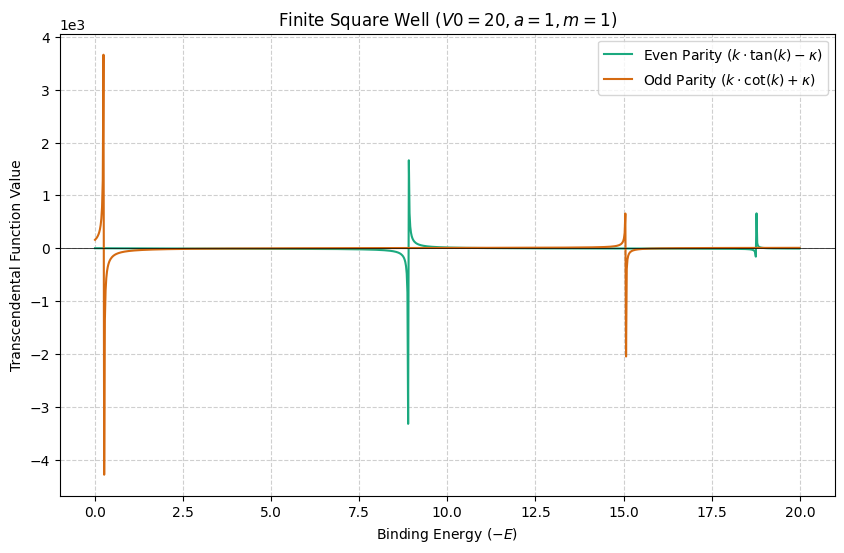

<Axes: title={'center': 'Finite Square Well ($V0=20, a=1, m = 1$)'}, xlabel='Binding Energy ($-E$)', ylabel='Transcendental Function Value'>

In [211]:
#   Excersice 1: PLOTTING
# ====================================================================================

# Defining constans
h_bar = 1
mass = 1
a = 1
width = 2 * a
V_0 = 20

# Energy variable epsilon = -E, range (0, V0)
eps = np.linspace(0.01, 19.99, 1000)

# Wave numbers (So simple because of natural Units system)
k = np.sqrt(2 * (V_0 - eps))
kappa = np.sqrt(2 * eps)

# ====================================================================================
# Even function: k*tan(k) - kappa
# ====================================================================================

# Handle singularities for tan
tan_k = np.tan(k)
# Set to NaN where cos(k) is close to 0 to avoid vertical lines
cos_k = np.cos(k)
mask_even = np.abs(cos_k) < 1e-3
tan_k[mask_even] = np.nan

f_even = k * tan_k - kappa


# ====================================================================================
# Odd function: -k*cot(k) - kappa  => -(k/tan(k)) - kappa
# ====================================================================================

# Handle singularities for cot (where sin(k) is close to 0)
sin_k = np.sin(k)
mask_odd = np.abs(sin_k) < 1e-3

cot_k = np.cos(k) / np.sin(k)
cot_k[mask_odd] = np.nan

f_odd = k * cot_k + kappa

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(
    eps, 
    f_even, 
    label=r'Even Parity ($k \cdot \tan(k) - \kappa$)',

    )
plt.plot(
    eps, 
    f_odd, 
    label=r'Odd Parity ($k \cdot \cot(k) + \kappa$)', 
    # linestyle='--'
    )

plt.axhline(0, color='black', linewidth=0.5)



# # Spike 1
# plt.xlim(0,1)

# # Spike 2
# plt.xlim(8.5,9.5)

# # Spike 3
# plt.xlim(14.5,15.5)

# # Spike 4
# plt.xlim(18.5,19.5)

# # Fokus on roots
# plt.ylim(-0.7,0.7)

pap.plot_me(f'Finite Square Well ($V0={V_0}, a={a}, m = {mass}$)', 'Binding Energy ($-E$)', 'Transcendental Function Value')

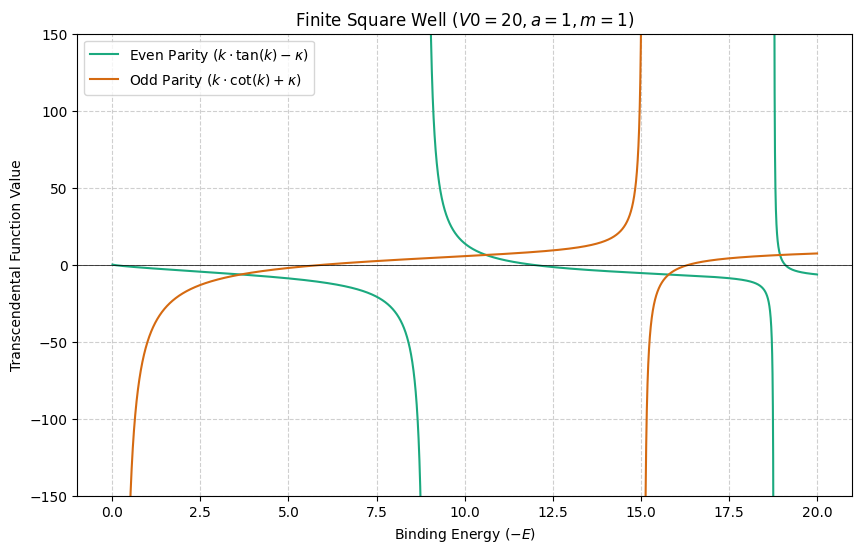

<Axes: title={'center': 'Finite Square Well ($V0=20, a=1, m = 1$)'}, xlabel='Binding Energy ($-E$)', ylabel='Transcendental Function Value'>

In [212]:
#   Excersice 1: PLOTTING WITH FOKUS ON ROOTS
# ====================================================================================
# Defining constans
h_bar = 1
mass = 1
a = 1
width = 2 * a
V_0 = 20

# Energy variable epsilon = -E, range (0, V0)
eps = np.linspace(0.01, 19.99, 10000)

# Wave numbers (So simple because of natural Units system)
k = np.sqrt(2 * (V_0 - eps))
kappa = np.sqrt(2 * eps)

# ====================================================================================
# Even function: k*tan(k) - kappa
# ====================================================================================

# Handle singularities for tan
tan_k = np.tan(k)
# Set to NaN where cos(k) is close to 0 to avoid vertical lines
cos_k = np.cos(k)
mask_even = np.abs(cos_k) < 1e-3
tan_k[mask_even] = np.nan

f_even = k * tan_k - kappa


# ====================================================================================
# Odd function: -k*cot(k) - kappa  => -(k/tan(k)) - kappa
# ====================================================================================

# Handle singularities for cot (where sin(k) is close to 0)
sin_k = np.sin(k)
mask_odd = np.abs(sin_k) < 1e-3

cot_k = np.cos(k) / np.sin(k)
cot_k[mask_odd] = np.nan

f_odd = k * cot_k + kappa

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(
    eps, 
    f_even, 
    label=r'Even Parity ($k \cdot \tan(k) - \kappa$)',
    )

plt.plot(
    eps, 
    f_odd, 
    label=r'Odd Parity ($k \cdot \cot(k) + \kappa$)', 
    # linestyle='--'
    )

plt.axhline(0, color='black', linewidth=0.5)

# # Fokus on roots
plt.ylim(-150,150)
# plt.ylim(-1.50,1.50)

pap.plot_me(f'Finite Square Well ($V0={V_0}, a={a}, m = {mass}$)', 'Binding Energy ($-E$)', 'Transcendental Function Value')

Notice: Setting the linespace to 1,000 also fixed the vertical line problem.

z0 = 6.32
3.0131684841794817
Expected bound states: \approx 3


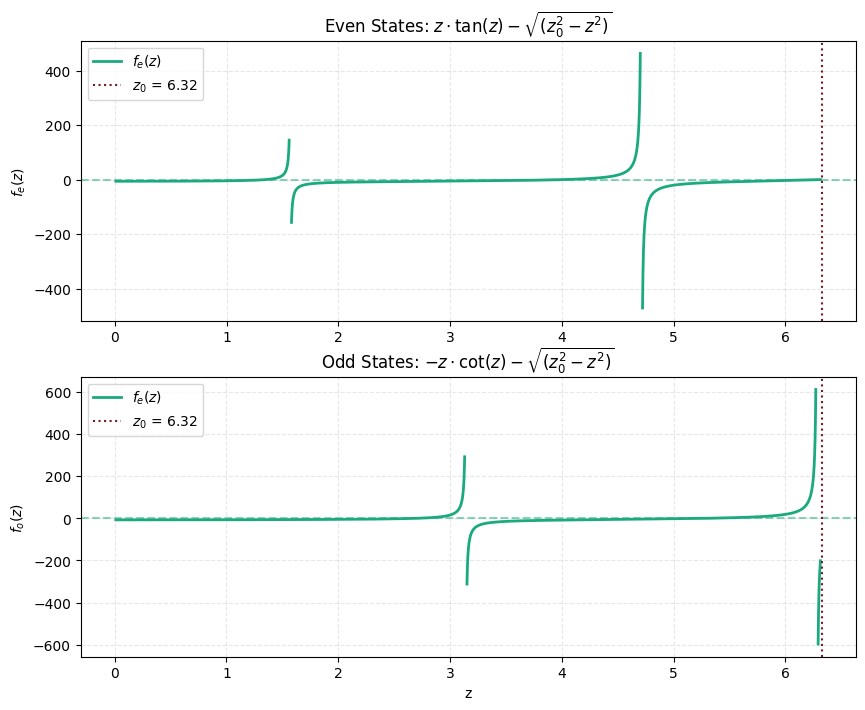

<Axes: title={'center': 'Odd States: $-z \\cdot \\cot(z) - \\sqrt{(z_0^2 - z^2)}$'}, xlabel='z', ylabel='$f_o(z)$'>

In [213]:
#   Excersice 1: PLOTTING and do it the intended way
# ====================================================================================

# Parameters/Konstants
h_bar = 1
m = 1
a = 1
V_0 = 20

# Calculate z_0
z_0 = a * np.sqrt(2 * m * V_0 / h_bar**2)
print(f"z0 = {z_0:.2f}")
print(z_0/np.pi + 1)
print(fr"Expected bound states: \approx {int(z_0/np.pi) + 1}")

# Define the functions 
def f_even(z):
    return z * np.tan(z) - np.sqrt(z_0**2 - z**2)

def f_odd(z):
    return -z / np.tan(z) - np.sqrt(z_0**2 - z**2)

# Create z array, avoiding singularities at z = pi/2, pi, 3pi/2, ... (halve Multiples of pi)
z = np.linspace(0.01, z_0 - 0.01, 10000)

# Handle singularities by masking
mask_even = np.abs(np.cos(z)) > 0.01  # tan(z) goes to infty when cos(z) \approx 0
mask_odd = np.abs(np.sin(z)) > 0.01   # cot(z) goes to infty when sin(z) \approx 0

# Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# # Even states
# ax[0].plot(
#     z[mask_even],
#     f_even(z)[mask_even], 
#     linewidth=2, 
#     label='$f_e(z)$'
#     )

# Cutting the function, thus the vertical liens disapeare
f_even_fixed = np.where(mask_even, f_even(z), np.nan)

ax[0].plot(
    z,
    f_even_fixed, 
    linewidth=2, 
    label='$f_e(z)$'
    )


# Line at 0
ax[0].axhline(y=0, linestyle='--', alpha=0.5)

# Line marking z_0
ax[0].axvline(x=z_0, linestyle=':', label=f'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)

ax[0].set_ylabel('$f_e(z)$')
ax[0].set_title(r'Even States: $z \cdot \tan(z) - \sqrt{(z_0^2 - z^2)}$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# # Odd states
# ax[1].plot(
#     z[mask_odd], 
#     f_odd(z)[mask_odd], 
#     linewidth=2, 
#     label='$f_o(z)$')

# Cutting the function, thus the vertical liens disapeare
f_odd_fixed = np.where(mask_odd, f_odd(z), np.nan)

ax[1].plot(
    z,
    f_odd_fixed, 
    linewidth=2, 
    label='$f_e(z)$'
    )

ax[1].axhline(y=0, linestyle='--', alpha=0.5)
ax[1].axvline(x=z_0, linestyle=':', label=fr'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)
ax[1].set_xlabel('z')
ax[1].set_ylabel('$f_o(z)$')
ax[1].set_title(r'Odd States: $-z \cdot \cot(z) - \sqrt{(z_0^2 - z^2)}$')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# # Fokus on Roots (visualising vertical lines that should be abolished)
# ax[0].set_ylim(-1,1)
# ax[1].set_ylim(-1,1)
# ax[1].set_xlim(2,3)


pap.plot_me()

Looking at the roots we see that all roots should be of multiplicity 1, since the function is somoot between the singulrities (peaks of tan/cotan), the slop at (around) the root point is $\not = 0$ and around the corssings there is no degenerate distribution (the function is continuous around the roots.)

<hr>

## Exercise 2: Root Finding
Implement the following methods: (5 pt.)
+ bisection
+ Newton method
+ secant method

Use all of them to compute one selected root. For each method measure and comment
on (3 pt.)
+ number of iterations
+ runtime
+ final residual

In [255]:
#   Excersice 2: Defining Functions to find roots
# ====================================================================================

def root_bi_section(function:sp, params, a:float, b:float, data = None, tolarance: float = 1e-4, max_iterations:int = 5000, while_loop: bool = True):
    '''
    Method to find the root of a given Functin between a given intervall [a,b].

    Params
    -----
    func : function to be analysed (sympy). Must be one dimensionl (one parameter!)
    params : Parameter of the function
        must be phrased as an array
    data : Values for teh parameters
        must be phrased as an array
    a : smaller (left) limit of intervall
    b : bigger (right) limit of intervall
    tolarance : How cloase the result should get
    max_iterations : exit crit 
    while_loop : iteration can change between while and for loop
        To check which method will be faster
    '''

    # Lambdify functions
    f = sp.lambdify(params, function, "numpy")

    # Calcualate initial values 
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        print('Nope, the signs do not match')
        raise ValueError('The initial contition that f(a) times f(b) > 0  is not satisfied')

    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'a': [],
        'b': [],
        'p': [],
        'f_p': [],
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0
    # total_time = 0.0

    if while_loop:
        # define recursive function to get closer and closer to the root
        i = 0
        while i < max_iterations:
            iter_start = time.perf_counter()
            # calculate the arethmetic mean of a and b and its value
            p = (a+b)/2
            fp = f(p)

            # Calculate error (width of the interval)
            error = (b - a) / 2

            iter_end = time.perf_counter()
            step_duration = iter_end - iter_start
            cumulative_time += step_duration

            # Store current iteration data
            log['iteration'].append(i)
            log['a'].append(a)
            log['b'].append(b)
            log['p'].append(p)
            log['f_p'].append(fp)
            log['error'].append(error)
            log['time_step'].append(step_duration)
            log['cumulative_time'].append(cumulative_time)

            if abs(fp) < tolarance or (b-a)/2 < tolarance:
                return p, log, total_time

            # check if either a or b must turn p
            if fa * fp < 0:
                b = p
                fb = fp
            else:
                a = p
                fa = fp

            i = i + 1
            total_time = time.perf_counter() - start_total_time
        
    else:
        for i in range(1, max_iterations + 1):
            iter_start = time.perf_counter()
            # calculate the arethmetic mean of a and b and its value
            p = (a+b)/2
            fp = f(p)
            
            # Calculate error (width of the interval)
            error = (b - a) / 2

            iter_end = time.perf_counter()
            step_duration = iter_end - iter_start
            cumulative_time += step_duration

            # Store current iteration data
            log['iteration'].append(i)
            log['a'].append(a)
            log['b'].append(b)
            log['p'].append(p)
            log['f_p'].append(fp)
            log['error'].append(error)
            log['time_step'].append(step_duration)
            log['cumulative_time'].append(cumulative_time)

            if abs(fp) < tolarance or (b-a)/2 < tolarance:
                return p, log, total_time

            # check if either a or b must turn p
            if fa * fp < 0:
                b = p
                fb = fp
            else:
                a = p
                fa = fp

            total_time = time.perf_counter() - start_total_time


def root_by_newt():
    print('Newton Method is in use')

def secant():
    print('Secant Method is in use')

def estimateIntervall(val:float, abw:float=10):
    '''
    Gets an estimated root and a percentage value to get quicker the intervall
    '''
    diff = val * abw / 100
    return val - diff, val + diff

def calc_z_0(V_0:int = 20):
    return a * np.sqrt(2 * m * V_0 / h_bar**2)

### Example of bisection

In [257]:
intervall = estimateIntervall(1.35, 10)
z = sym.z
z_0 = calc_z_0(20)
func_even = z * sp.tan(z) - sp.sqrt(z_0**2 - z**2)

a = intervall[0]
b = intervall[1]
tol = 1e-15 # Why does it brak after e-15  -> Single Float limit

print(f'Intervall is set to: I = [{intervall[0]:.4f}, {intervall[1]:.4f}]')
root, log, timer = root_bi_section(func_even, [z], a, b, tolarance=tol, while_loop=True)

print(f'The root is (approximately) at: x = {root:.5f}')
print(f'Iterationen: {len(log['iteration'])}\nCalculation Time: {timer:.3g}s')

print('=========================')

intervall = estimateIntervall(2.7, 10)
func_odd = -z / sp.tan(z) - sp.sqrt(z_0**2 - z**2)

a = intervall[0]
b = intervall[1]
tol = 1e-15 # Why does it brak after e-15?

print(f'Intervall is set to: I = [{intervall[0]:.4f}, {intervall[1]:.4f}]')
root, log, timer = root_bi_section(func_odd, [z], a, b, tolarance=tol, while_loop=True)

print(f'The root is (approximately) at: x = {root:.5f}')
print(f'Iterationen: {len(log['iteration'])}\nCalculation Time: {timer:.3g}s')

Intervall is set to: I = [1.2150, 1.4850]
The root is (approximately) at: x = 1.47469
Iterationen: 48
Calculation Time: 0.000303s
Intervall is set to: I = [2.4300, 2.9700]
The root is (approximately) at: x = 2.94854
Iterationen: 49
Calculation Time: 0.00028s


(1.465, 1.48)

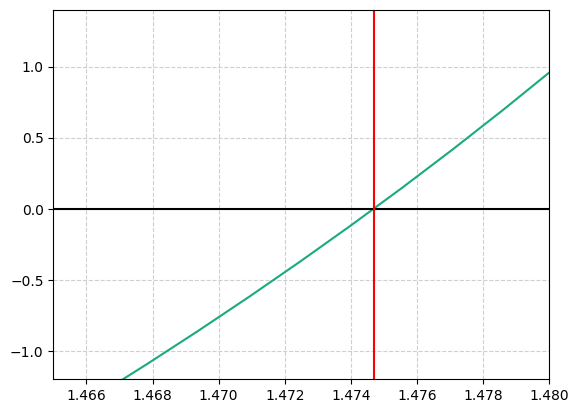

In [245]:
x = np.linspace(0, calc_z_0(20), 10000)
plt.plot(x, f_even(x))
plt.hlines(0, 0, z_0, 'black')
plt.vlines(1.47469, 10, -10, 'red')
plt.ylim(-1.2,1.4)
plt.xlim(1.465,1.48)

<hr>

## Exercise 3: Automatic Detection of All Roots (7 pt.)
Construct an automated algorithm that finds all roots of $f_e(z) = 0$ and $f_o(z) = 0$ in
the interval $0 < z < z_0$. Split the interval in a clever way. Compute all bound-state
energies. Why is the parity-separated formulation numerically useful?

<hr>

## Exercise 4: Speed vs Accuracy (3 pt.)
For one root compare the methods for tolerances
$$10^{−4}, 10^{−8}, 10^{−12}.$$
Create:
+ a table of iterations and runtime
+ a plot of runtime vs residual
+ a short discussion

<hr>

## Exercise 5: Dependence on Well Depth (optional 3 pt.)
Repeat the analysis for
$$V_0 = 5, 10, 20, 50.$$
Comment on the number of bound states and on the behaviour of the roots with
increasing $V_0$ (location/slope). What happens for $V_0 \to \infty$? Comment on the accuracy
of a root $z$ for a given stopping criterion based on the value of $f(z) (|f (z)| < eps)$.